In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pvlib

In [130]:
data_path = r"data\processeddata.parquet"
df = pd.read_parquet(data_path)

In [132]:
cpu_columns = ['STATION CPU TEMPERATURE (°C)',
                'STATION BATTERY VOLTAGE (V)']

df.drop(columns=cpu_columns, inplace=True)

In [134]:
ghi_path = r"data\ghi_cs_calculado.parquet"
df_GHIcs = pd.read_parquet(ghi_path)

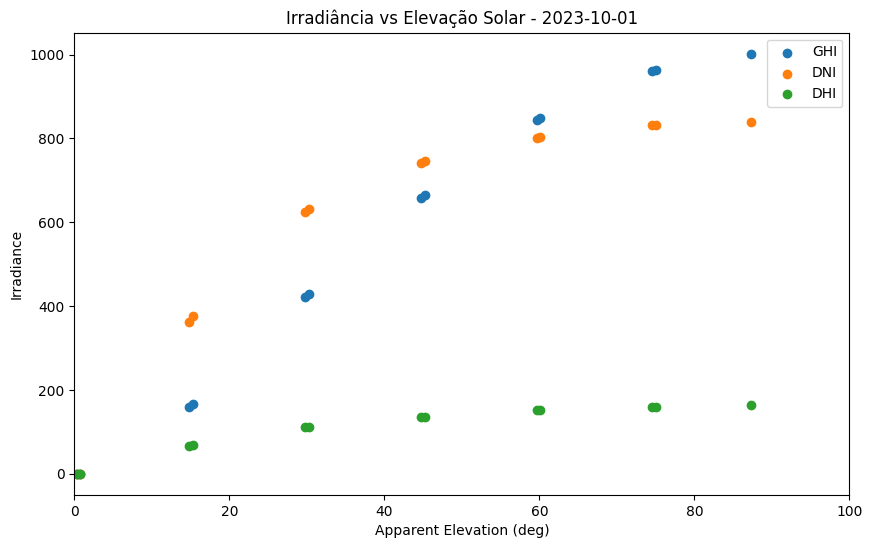

In [143]:
plot_columns = ['ghi', 'dni', 'dhi', 'GLOBAL RADIATION (Kj/m²)','apparent_zenith']

latitude_estacao = -0.61888888
longitude_estacao = -47.35666666
altitude_estacao = 23.18 # em metros

solpos = pvlib.solarposition.get_solarposition(df_GHIcs.index, 
                                               latitude_estacao, 
                                               longitude_estacao, 
                                               altitude=altitude_estacao)

df_GHIcs['apparent_elevation'] = solpos['apparent_elevation']
aod700 =0.1
precipitable_water = 1
pressure = 101325

dni_extra = 1364

solis = pvlib.clearsky.simplified_solis(df_GHIcs['apparent_elevation'], aod700,
                                  precipitable_water, pressure, dni_extra)

pressure = pvlib.atmosphere.alt2pres(altitude_estacao)
dni_extra = pvlib.irradiance.get_extra_radiation(df_GHIcs.index)
# Seleciona apenas os dados do dia desejado
dia = '2023-10-01'  
df_day = df_GHIcs[df_GHIcs.index.date == pd.to_datetime(dia).date()]

# Faz o reamostramento diário (embora para um dia só não altere os dados)
df_day_resampled = df_day.resample('h').mean()
df_day = df_day[(df_day['apparent_elevation']>0)]

plt.figure(figsize=(10, 6))
plt.scatter(df_day['apparent_elevation'], df_day['ghi'], label='GHI')
plt.scatter(df_day['apparent_elevation'], df_day['dni'], label='DNI')
plt.scatter(df_day['apparent_elevation'], df_day['dhi'], label='DHI')
plt.xlabel('Apparent Elevation (deg)')
plt.ylabel('Irradiance')
plt.xlim(0, 100)
plt.title(f'Irradiância vs Elevação Solar - {dia}')
plt.legend()
plt.show()


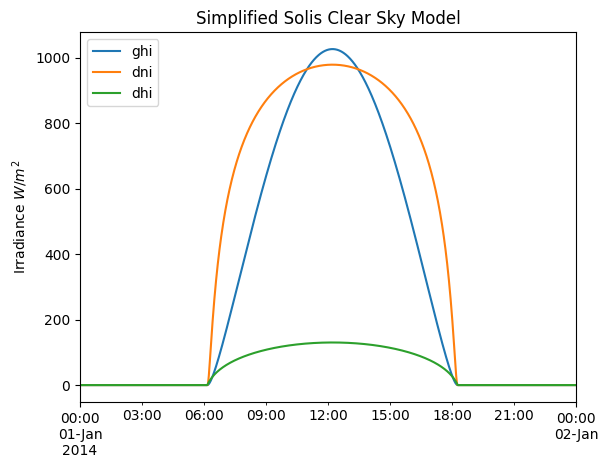

In [138]:
latitude, longitude, tz, altitude, name = latitude_estacao, longitude_estacao, 'America/Belem', altitude_estacao, 'Salinopolis'

times = pd.date_range(start='2014-01-01', end='2014-01-02', freq='1Min', tz=tz)

solpos = pvlib.solarposition.get_solarposition(times, latitude, longitude)

apparent_elevation = solpos['apparent_elevation']

aod700 = 0.1

precipitable_water = 1

pressure = pvlib.atmosphere.alt2pres(altitude)

dni_extra = pvlib.irradiance.get_extra_radiation(times)


solis = pvlib.clearsky.simplified_solis(apparent_elevation, aod700, precipitable_water,
                                  pressure, dni_extra)


ax = solis.plot()

ax.set_ylabel('Irradiance $W/m^2$')

ax.set_title('Simplified Solis Clear Sky Model')

ax.legend(loc=2)

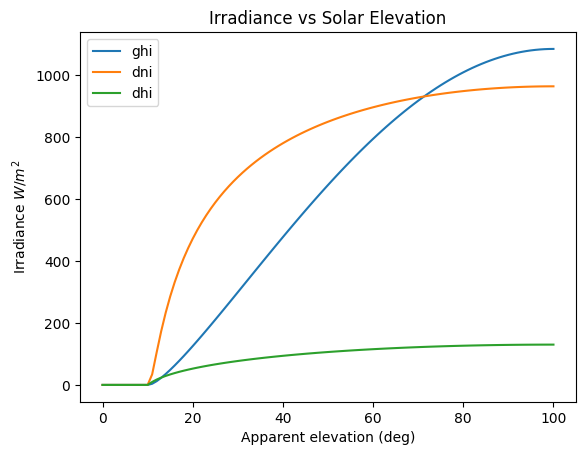

In [139]:
apparent_elevation = pd.Series(np.linspace(-10, 90, 101))

aod700 = 0.1

precipitable_water = 1

pressure = 101325

dni_extra = 1364

solis = pvlib.clearsky.simplified_solis(apparent_elevation, aod700,
                                  precipitable_water, pressure, dni_extra)


ax = solis.plot()

ax.set_xlabel('Apparent elevation (deg)')
ax.set_ylabel('Irradiance $W/m^2$')

ax.set_title('Irradiance vs Solar Elevation')


ax.legend(loc=2)

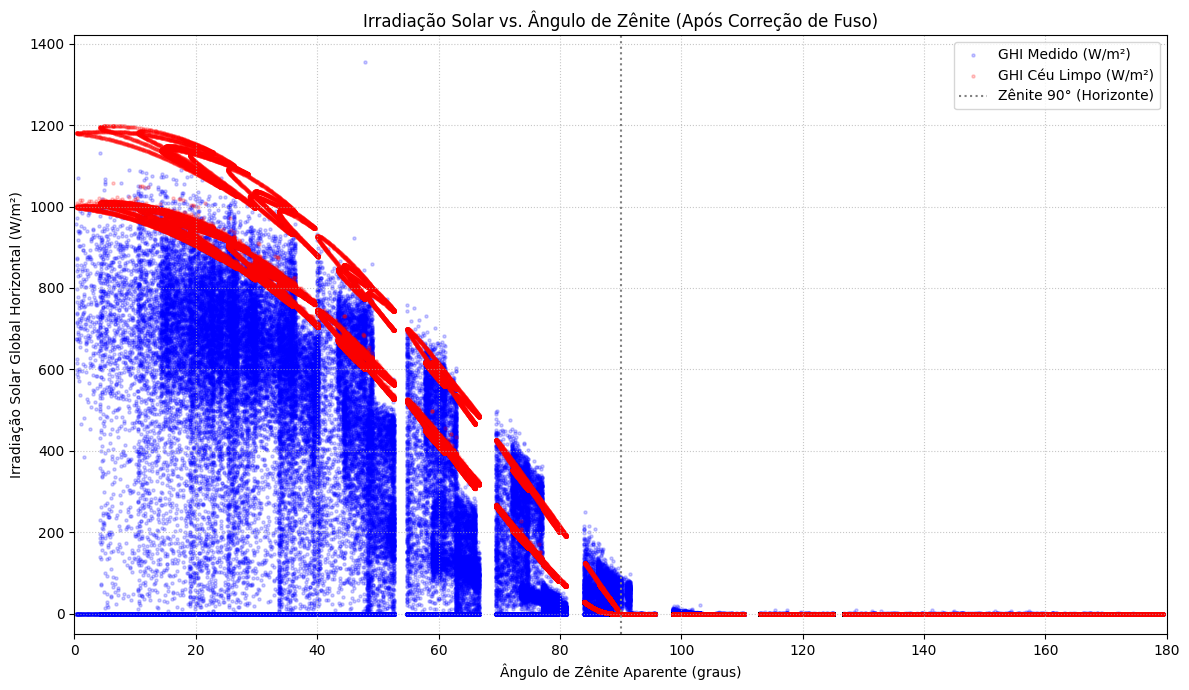


Número de registros antes do filtro de zênite (alvorada/crepúsculo): 63271
Número de registros após filtro de zênite < 85.0°: 63271


C:\Users\Josué Dias\AppData\Local\Temp\ipykernel_12360\1005456329.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filtrado_dia['kt'].fillna(0, inplace=True)



DataFrame (filtrado por zênite) com kt calculado:
                           GLOBAL RADIATION (Kj/m²)  GHI_measured_Wm2  \
Data_Hora                                                               
2008-06-13 07:00:00-03:00                       0.0               0.0   
2008-06-13 08:00:00-03:00                       0.0               0.0   
2008-06-13 09:00:00-03:00                       0.0               0.0   
2008-06-13 10:00:00-03:00                       0.0               0.0   
2008-06-13 11:00:00-03:00                       0.0               0.0   

                           GHIcs_Ineichen  apparent_zenith   kt  
Data_Hora                                                        
2008-06-13 07:00:00-03:00      225.781183        78.677831  0.0  
2008-06-13 08:00:00-03:00      484.761452        65.069475  0.0  
2008-06-13 09:00:00-03:00      710.374203        51.851769  0.0  
2008-06-13 10:00:00-03:00      887.248131        39.511503  0.0  
2008-06-13 11:00:00-03:00     1003.332771

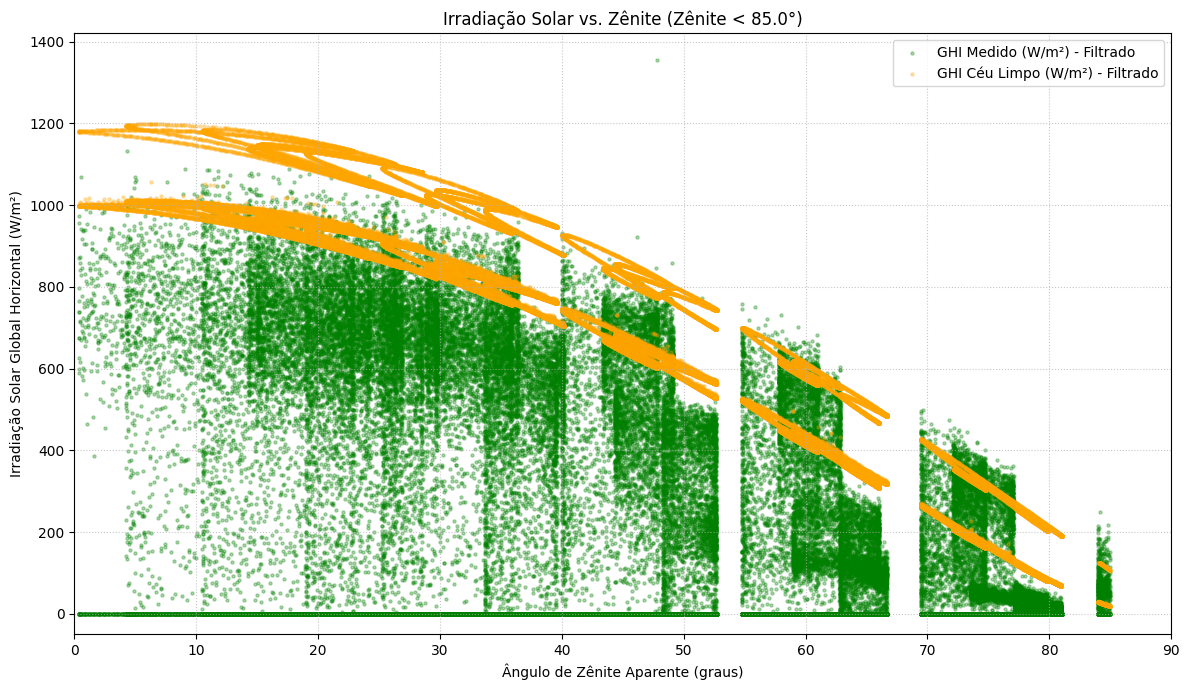

In [150]:
# --- 7. Plotar GHI vs. Ângulo de Zênite para Verificação ---
fuso_horario_local_str = 'America/Belem'

df_plot = pd.read_parquet(r"data\Salinopolis_GHI_ClearSky_Calculado_FusoCorrigido.parquet") 

if 'GLOBAL RADIATION (Kj/m²)' in df_plot.columns:
    df_plot['GHI_measured_Wm2_plot'] = df_plot['GLOBAL RADIATION (Kj/m²)'] / 3.6
    df_plot.loc[df_plot['GHI_measured_Wm2_plot'] < 0, 'GHI_measured_Wm2_plot'] = 0

    fig, ax_scatter = plt.subplots(figsize=(12, 7))
    ax_scatter.scatter(df_plot['apparent_zenith'], df_plot['GHI_measured_Wm2_plot'],
                       label='GHI Medido (W/m²)', color='blue', alpha=0.2, s=5)
    if 'GHIcs_Ineichen' in df_plot.columns:
        ax_scatter.scatter(df_plot['apparent_zenith'], df_plot['GHIcs_Ineichen'],
                           label='GHI Céu Limpo (W/m²)', color='red', alpha=0.2, s=5)
    ax_scatter.set_xlabel("Ângulo de Zênite Aparente (graus)")
    ax_scatter.set_ylabel("Irradiação Solar Global Horizontal (W/m²)")
    ax_scatter.set_title("Irradiação Solar vs. Ângulo de Zênite (Após Correção de Fuso)")
    ax_scatter.set_xlim(0, 180)
    ax_scatter.set_ylim(bottom=-50)
    ax_scatter.axvline(90, color='gray', linestyle=':', label='Zênite 90° (Horizonte)')
    ax_scatter.grid(True, linestyle=':', alpha=0.7)
    ax_scatter.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Coluna 'GLOBAL RADIATION (Kj/m²)' não encontrada para plotagem de verificação.")


# --- 8. Aplicar Filtro de Zênite e Calcular kt ---
# Carregar o DataFrame com os cálculos de céu limpo e fuso corrigido
df_para_analise = pd.read_parquet(r"data\Salinopolis_kt_Calculado_FusoCorrigido_Zenith85.parquet")
# Certificar que o índice está no fuso horário correto (deve estar se foi salvo corretamente)
if df_para_analise.index.tzinfo is None:
    df_para_analise.index = df_para_analise.index.tz_localize('UTC').tz_convert(fuso_horario_local_str)
elif df_para_analise.index.tzinfo.zone != fuso_horario_local_str:
    df_para_analise.index = df_para_analise.index.tz_convert(fuso_horario_local_str)

print(f"\nNúmero de registros antes do filtro de zênite (alvorada/crepúsculo): {len(df_para_analise)}")

# Definir o limiar de zênite para remover alvorada/crepúsculo
# Valores menores que este serão mantidos (sol mais alto)
zenith_threshold_day = 85.0 
daylight_filter_strict = df_para_analise['apparent_zenith'] < zenith_threshold_day
df_filtrado_dia = df_para_analise[daylight_filter_strict].copy() # Usar .copy() para evitar SettingWithCopyWarning

print(f"Número de registros após filtro de zênite < {zenith_threshold_day}°: {len(df_filtrado_dia)}")

# Prosseguir com o cálculo de kt usando o df_filtrado_dia
df_filtrado_dia['GHI_measured_Wm2'] = df_filtrado_dia['GLOBAL RADIATION (Kj/m²)'] / 3.6
df_filtrado_dia.loc[df_filtrado_dia['GHI_measured_Wm2'] < 0, 'GHI_measured_Wm2'] = 0

ghi_cs_min_threshold = 1 # W/m²
df_filtrado_dia['kt'] = np.nan

# Calcular kt apenas onde GHIcs_Ineichen é significativo (e agora, apenas para os dados já filtrados pelo zênite)
condition_daytime_kt = df_filtrado_dia['GHIcs_Ineichen'] >= ghi_cs_min_threshold
df_filtrado_dia.loc[condition_daytime_kt, 'kt'] = \
    df_filtrado_dia['GHI_measured_Wm2'][condition_daytime_kt] / df_filtrado_dia['GHIcs_Ineichen'][condition_daytime_kt]

# Tratamento de Valores de kt
kt_max_cap = 1.2 # Exemplo, ajuste conforme necessário
df_filtrado_dia.loc[df_filtrado_dia['kt'] > kt_max_cap, 'kt'] = kt_max_cap
df_filtrado_dia.loc[df_filtrado_dia['kt'] < 0, 'kt'] = 0 # Deve ser redundante se GHI_measured_Wm2 >=0
# Preencher NaNs restantes em 'kt' (se GHIcs_Ineichen < ghi_cs_min_threshold mesmo após filtro de zênite)
df_filtrado_dia['kt'].fillna(0, inplace=True) 

print("\nDataFrame (filtrado por zênite) com kt calculado:")
print(df_filtrado_dia[['GLOBAL RADIATION (Kj/m²)', 'GHI_measured_Wm2', 'GHIcs_Ineichen', 'apparent_zenith', 'kt']].head())
print(f"\nDescrição estatística de kt (dados filtrados por zênite < {zenith_threshold_day}°):")
print(df_filtrado_dia['kt'].describe())

# Salvar o DataFrame final que contém kt e está filtrado
output_path_kt_filtrado = f'data/Salinopolis_kt_Calculado_FusoCorrigido_Zenith{int(zenith_threshold_day)}.parquet'
df_filtrado_dia.to_parquet(output_path_kt_filtrado)
print(f"\nDataFrame com kt (fuso corrigido e zênite < {zenith_threshold_day}°) salvo em: {output_path_kt_filtrado}")

# Plotar o GHI vs Zênite para o df_filtrado_dia para ver o efeito do filtro
if 'GLOBAL RADIATION (Kj/m²)' in df_filtrado_dia.columns:
    fig, ax_scatter_filtrado = plt.subplots(figsize=(12, 7))
    ax_scatter_filtrado.scatter(df_filtrado_dia['apparent_zenith'], df_filtrado_dia['GHI_measured_Wm2'],
                       label='GHI Medido (W/m²) - Filtrado', color='green', alpha=0.3, s=5)
    if 'GHIcs_Ineichen' in df_filtrado_dia.columns:
        ax_scatter_filtrado.scatter(df_filtrado_dia['apparent_zenith'], df_filtrado_dia['GHIcs_Ineichen'],
                           label='GHI Céu Limpo (W/m²) - Filtrado', color='orange', alpha=0.3, s=5)
    ax_scatter_filtrado.set_xlabel("Ângulo de Zênite Aparente (graus)")
    ax_scatter_filtrado.set_ylabel("Irradiação Solar Global Horizontal (W/m²)")
    ax_scatter_filtrado.set_title(f"Irradiação Solar vs. Zênite (Zênite < {zenith_threshold_day}°)")
    ax_scatter_filtrado.set_xlim(0, zenith_threshold_day + 5) # Ajustar xlim para o intervalo filtrado
    ax_scatter_filtrado.set_ylim(bottom=-50)
    ax_scatter_filtrado.grid(True, linestyle=':', alpha=0.7)
    ax_scatter_filtrado.legend()
    plt.tight_layout()
    plt.show()


In [151]:
df_filtrado_dia.columns

Index(['TOTAL PRECIPITATION, HOURLY (mm)',
       'ATMOSPHERIC PRESSURE AT STATION LEVEL, HOURLY (mB)',
       'ATMOSPHERIC PRESSURE REDUCED TO SEA LEVEL, AUT (mB)',
       'ATMOSPHERIC PRESSURE MAX. IN THE PREVIOUS HOUR (AUT) (mB)',
       'ATMOSPHERIC PRESSURE MIN. IN THE PREVIOUS HOUR (AUT) (mB)',
       'GLOBAL RADIATION (Kj/m²)', 'STATION CPU TEMPERATURE (°C)',
       'AIR TEMPERATURE - DRY BULB, HOURLY (°C)', 'DEW POINT TEMPERATURE (°C)',
       'MAXIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'MINIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'MAXIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'MINIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'STATION BATTERY VOLTAGE (V)',
       'RELATIVE HUMIDITY MAX. IN THE PREVIOUS HOUR (AUT) (%)',
       'RELATIVE HUMIDITY MIN. IN THE PREVIOUS HOUR (AUT) (%)',
       'AIR RELATIVE HUMIDITY, HOURLY (%)',
       'WIND, HOURLY DIRECTION (gr) (° (gr))', 'WIND, MAXIMUM GUST (m/s)'